In [1]:
from scipy.io import arff
import pandas as pd

# ARFF-Datei einlesen
data, meta = arff.loadarff('dataset')

# In ein Pandas DataFrame umwandeln
df = pd.DataFrame(data)
print(df.head())

     var_0   var_1    var_2   var_3    var_4   var_5   var_6    var_7   var_8  \
0   8.9255 -6.7863  11.9081  5.0930  11.4607 -9.2834  5.1187  18.6266 -4.9200   
1  11.5006 -4.1473  13.8588  5.3890  12.3622  7.0433  5.6208  16.5338  3.1468   
2   8.6093 -2.7457  12.0805  7.8928  10.5825 -9.0837  6.9427  14.6155 -4.9193   
3  11.0604 -2.1518   8.9522  7.1957  12.5846 -1.8361  5.8428  14.9250 -5.8609   
4   9.8369 -1.4834  12.8746  6.6375  12.2772  2.4486  5.9405  19.2514  6.2654   

    var_9  ...  var_191  var_192  var_193  var_194  var_195  var_196  var_197  \
0  5.7470  ...   3.9642   3.1364   1.6910  18.5227  -2.3978   7.8784   8.5635   
1  8.0851  ...   7.7214   2.5837  10.9516  15.4305   2.0339   8.1267   8.7889   
2  5.9525  ...   9.7905   1.6704   1.6858  21.6042   3.1417  -6.5213   8.2675   
3  8.2450  ...   4.7433   0.7178   1.4214  23.0347  -1.2706  -2.9275  10.2922   
4  7.6784  ...   9.5214  -0.1508   9.1942  13.2876  -1.5121   3.9267   9.5031   

   var_198  var_199    tar

# Santander Customer Transaction Prediction – Offline EDA

In [2]:
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Lokale Datei finden

In [3]:
FILE_PATH = Path.cwd() / "dataset"

print("Arbeitsordner:", Path.cwd().resolve())
print("Datensatz:", FILE_PATH.resolve())
print("Existiert:", FILE_PATH.exists())
print("Ist Datei:", FILE_PATH.is_file())

if not FILE_PATH.exists():
    raise FileNotFoundError(
        "Die Datei 'dataset' wurde nicht im gleichen Ordner wie das Notebook gefunden."
    )

if not FILE_PATH.is_file():
    raise ValueError("'dataset' ist keine Datei.")


Arbeitsordner: C:\Users\ausanay\Desktop\ADA_Project\Ang
Datensatz: C:\Users\ausanay\Desktop\ADA_Project\Ang\dataset
Existiert: True
Ist Datei: True


## 2. Lokale Dateimetadaten

In [4]:
file_size_mb = FILE_PATH.stat().st_size / 1024**2
local_modified = datetime.fromtimestamp(FILE_PATH.stat().st_mtime)

display(pd.DataFrame({
    "Merkmal": [
        "Dateiname",
        "Dateiendung",
        "Dateigröße",
        "Lokales Änderungsdatum",
        "Absoluter Pfad"
    ],
    "Wert": [
        FILE_PATH.name,
        FILE_PATH.suffix if FILE_PATH.suffix else "keine",
        f"{file_size_mb:,.2f} MB",
        local_modified.strftime("%d.%m.%Y %H:%M:%S"),
        str(FILE_PATH.resolve())
    ]
}))


,Merkmal,Wert
0,Dateiname,dataset
1,Dateiendung,keine
2,Dateigröße,298.39 MB
3,Lokales Änderungsdatum,30.07.2026 16:32:44
4,Absoluter Pfad,C:\Users\ausanay\Desktop\ADA_Project\Ang\dataset


## 3. Format automatisch erkennen und laden

In [5]:
with open(FILE_PATH, "rb") as file:
    header = file.read(2000)

if header.startswith(b"PAR1"):
    detected_format = "Parquet"
    df = pd.read_parquet(FILE_PATH)

elif header.startswith(b"PK"):
    detected_format = "ZIP-komprimierte CSV"
    df = pd.read_csv(FILE_PATH, compression="zip", low_memory=False)

elif header.startswith(b"\x1f\x8b"):
    detected_format = "GZIP-komprimierte CSV"
    df = pd.read_csv(FILE_PATH, compression="gzip", low_memory=False)

elif b"@relation" in header.lower() or b"@attribute" in header.lower():
    detected_format = "ARFF"
    from scipy.io import arff
    data, metadata = arff.loadarff(FILE_PATH)
    df = pd.DataFrame(data)

    for column in df.select_dtypes(include="object").columns:
        df[column] = df[column].map(
            lambda value: value.decode("utf-8")
            if isinstance(value, bytes) else value
        )

else:
    detected_format = "CSV/Text"
    try:
        df = pd.read_csv(FILE_PATH, low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(FILE_PATH, encoding="latin1", low_memory=False)

print("Erkanntes Format:", detected_format)
print("Form:", df.shape)
display(df)


Erkanntes Format: ARFF
Form: (200000, 201)


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,...,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914,False
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,...,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518,False
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,...,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965,False
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,...,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996,False
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,...,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,-0.6209,5.6669,...,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661,False
199996,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,-3.6797,6.0019,...,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388,False
199997,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,0.1202,6.1629,...,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995,False
199998,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,-2.1926,8.7542,...,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001,False


## 4. Bekannte Metadaten

In [6]:
display(pd.DataFrame({
    "Merkmal": [
        "Titel",
        "Aufgabentyp",
        "Ziel",
        "Kontext",
        "Ursprung",
        "Jahr",
        "OpenML-ID",
        "Lokales Format"
    ],
    "Information": [
        "Santander Customer Transaction Prediction",
        "Binäre Klassifikation",
        "Vorhersage, ob eine Person eine Transaktion durchführen wird",
        "Finanztransaktionen",
        "Kaggle Competition",
        "2019",
        "45566",
        detected_format
    ]
}))


,Merkmal,Information
0,Titel,Santander Customer Transaction Prediction
1,Aufgabentyp,Binäre Klassifikation
2,Ziel,"Vorhersage, ob eine Person eine Transaktion du..."
3,Kontext,Finanztransaktionen
4,Ursprung,Kaggle Competition
5,Jahr,2019
6,OpenML-ID,45566
7,Lokales Format,ARFF


## 5. Struktur und Datentypen

In [7]:
id_candidates = ["ID_code", "id", "ID"]
target_candidates = ["target", "Target", "TARGET"]

ID_COLUMN = next((c for c in id_candidates if c in df.columns), None)
TARGET_COLUMN = next((c for c in target_candidates if c in df.columns), None)

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
feature_columns = [c for c in numeric_columns if c != TARGET_COLUMN]

display(pd.DataFrame({
    "Merkmal": [
        "Zeilen",
        "Spalten",
        "Numerische Spalten",
        "Numerische Features",
        "ID-Spalte",
        "Zielvariable",
        "Dateigröße",
        "RAM-Verbrauch"
    ],
    "Wert": [
        df.shape[0],
        df.shape[1],
        len(numeric_columns),
        len(feature_columns),
        ID_COLUMN if ID_COLUMN else "nicht erkannt",
        TARGET_COLUMN if TARGET_COLUMN else "nicht erkannt",
        f"{file_size_mb:,.2f} MB",
        f"{df.memory_usage(deep=True).sum() / 1024**2:,.2f} MB"
    ]
}))

display(df.dtypes.value_counts().rename("Anzahl"))
df.info(memory_usage="deep")


,Merkmal,Wert
0,Zeilen,200000
1,Spalten,201
2,Numerische Spalten,200
3,Numerische Features,200
4,ID-Spalte,nicht erkannt
5,Zielvariable,target
6,Dateigröße,298.39 MB
7,RAM-Verbrauch,315.46 MB


float64    200
str          1
Name: Anzahl, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 201 entries, var_0 to target
dtypes: float64(200), str(1)
memory usage: 315.5 MB


## 6. Erste Zeilen

In [8]:
display(df.head())
display(df.tail())
display(df.sample(5, random_state=42))


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,...,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914,False
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,...,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518,False
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,...,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965,False
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,...,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996,False
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,...,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104,False


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
199995,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,-0.6209,5.6669,...,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661,False
199996,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,-3.6797,6.0019,...,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388,False
199997,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,0.1202,6.1629,...,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995,False
199998,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,-2.1926,8.7542,...,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001,False
199999,10.8762,-5.7105,12.1183,8.0328,11.5577,0.3488,5.2839,15.2058,-0.4541,9.3688,...,1.6893,0.1276,0.3766,15.2101,-2.4907,-2.2342,8.1857,12.1284,0.1385,False


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199,target
119737,11.0038,-4.5026,9.0662,6.4313,10.7061,-15.2857,5.1233,16.7875,4.1833,8.4055,...,3.3085,3.1358,5.0959,19.7160,-0.1801,5.8437,8.8348,17.0461,8.8190,False
72272,12.8473,-6.1848,6.8799,2.0164,12.7998,10.2781,4.4191,15.6940,-0.6788,8.9070,...,3.9019,4.6616,7.6035,12.6402,-0.3037,-4.2330,9.7456,14.8337,-3.7167,False
158154,13.1827,-0.8344,13.4689,3.9060,13.5984,4.6475,5.9659,24.0557,3.8743,7.6350,...,5.8939,0.8525,8.7406,16.6641,0.8745,7.0406,8.6424,20.7107,-5.4186,False
65426,8.2132,1.2309,11.1464,9.4524,10.2142,4.0416,5.3989,20.4527,0.2915,6.3123,...,5.7442,2.1907,6.0651,10.9444,-2.0666,-7.9209,9.0522,17.1735,12.4656,False
30074,5.5681,4.6355,15.2350,3.0718,11.8178,-15.0502,3.8357,12.0169,3.2997,6.3261,...,5.6113,-0.1561,3.1010,17.4297,-1.0121,-6.5168,7.9772,18.5248,11.2771,True


## 7. Datenqualität

In [9]:
missing_per_column = df.isna().sum()
duplicate_rows = int(df.duplicated().sum())

print("Fehlende Werte insgesamt:", int(missing_per_column.sum()))
print("Doppelte Zeilen:", duplicate_rows)

if ID_COLUMN:
    print("Doppelte IDs:", int(df[ID_COLUMN].duplicated().sum()))

display(pd.DataFrame({
    "Fehlende_Werte": missing_per_column,
    "Anteil_Prozent": missing_per_column / len(df) * 100
}).sort_values("Fehlende_Werte", ascending=False).head(20))

constant_columns = [
    c for c in df.columns
    if df[c].nunique(dropna=False) <= 1
]
print("Konstante Spalten:", constant_columns if constant_columns else "keine")


Fehlende Werte insgesamt: 0
Doppelte Zeilen: 0


,Fehlende_Werte,Anteil_Prozent
var_0,0,0.0000
var_1,0,0.0000
var_2,0,0.0000
var_3,0,0.0000
var_4,0,0.0000
var_5,0,0.0000
var_6,0,0.0000
var_7,0,0.0000
var_8,0,0.0000
var_9,0,0.0000


Konstante Spalten: keine


## 8. Speicheroptimierung mit float32

In [10]:
df_optimized = df.copy()

for column in df_optimized.select_dtypes(include=["float64"]).columns:
    if column != TARGET_COLUMN:
        df_optimized[column] = df_optimized[column].astype("float32")

memory_before = df.memory_usage(deep=True).sum() / 1024**2
memory_after = df_optimized.memory_usage(deep=True).sum() / 1024**2

display(pd.DataFrame({
    "Variante": ["Original", "Optimiert"],
    "RAM_MB": [memory_before, memory_after]
}))

print(f"Einsparung: {100 * (1 - memory_after / memory_before):.2f} %")


,Variante,RAM_MB
0,Original,315.4564
1,Optimiert,162.8685


Einsparung: 48.37 %


## 9. Statistische Übersicht

In [11]:
if feature_columns:
    stats = df[feature_columns].describe().T
    stats["missing"] = df[feature_columns].isna().sum()
    stats["unique"] = df[feature_columns].nunique()
    display(stats.head(20))


,count,mean,std,min,25%,50%,75%,max,missing,unique
var_0,"200,000.0000",10.6799,3.0401,0.4084,8.4539,10.5248,12.7582,20.3150,0,94672
var_1,"200,000.0000",-1.6276,4.0500,-15.0434,-4.7400,-1.6080,1.3586,10.3768,0,108932
var_2,"200,000.0000",10.7152,2.6409,2.1171,8.7225,10.5800,12.5167,19.3530,0,86555
var_3,"200,000.0000",6.7965,2.0433,-0.0402,5.2541,6.8250,8.3241,13.1883,0,74597
var_4,"200,000.0000",11.0783,1.6231,5.0748,9.8832,11.1082,12.2611,16.6714,0,63515
var_5,"200,000.0000",-5.0653,7.8633,-32.5626,-11.2004,-4.8331,0.9248,17.2516,0,141029
var_6,"200,000.0000",5.4089,0.8666,2.3473,4.7677,5.3851,6.0030,8.4477,0,38599
var_7,"200,000.0000",16.5458,3.4181,5.3497,13.9438,16.4568,19.1029,27.6918,0,103063
var_8,"200,000.0000",0.2842,3.3326,-10.5055,-2.3178,0.3937,2.9379,10.1513,0,98617
var_9,"200,000.0000",7.5672,1.2351,3.9705,6.6188,7.6296,8.5844,11.1506,0,49417


## 10. Zielvariable

,Anzahl,Anteil_Prozent
target,,
False,179902,89.9510
True,20098,10.0490


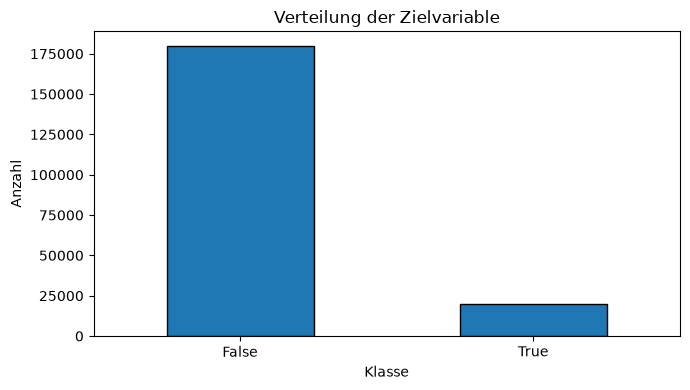

In [12]:
if TARGET_COLUMN:
    counts = df[TARGET_COLUMN].value_counts(dropna=False).sort_index()
    shares = df[TARGET_COLUMN].value_counts(
        normalize=True, dropna=False
    ).sort_index() * 100

    display(pd.DataFrame({
        "Anzahl": counts,
        "Anteil_Prozent": shares
    }))

    ax = counts.plot(kind="bar", figsize=(7, 4), edgecolor="black")
    ax.set_title("Verteilung der Zielvariable")
    ax.set_xlabel("Klasse")
    ax.set_ylabel("Anzahl")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Zielvariable erkannt.")


## 11. Histogramme

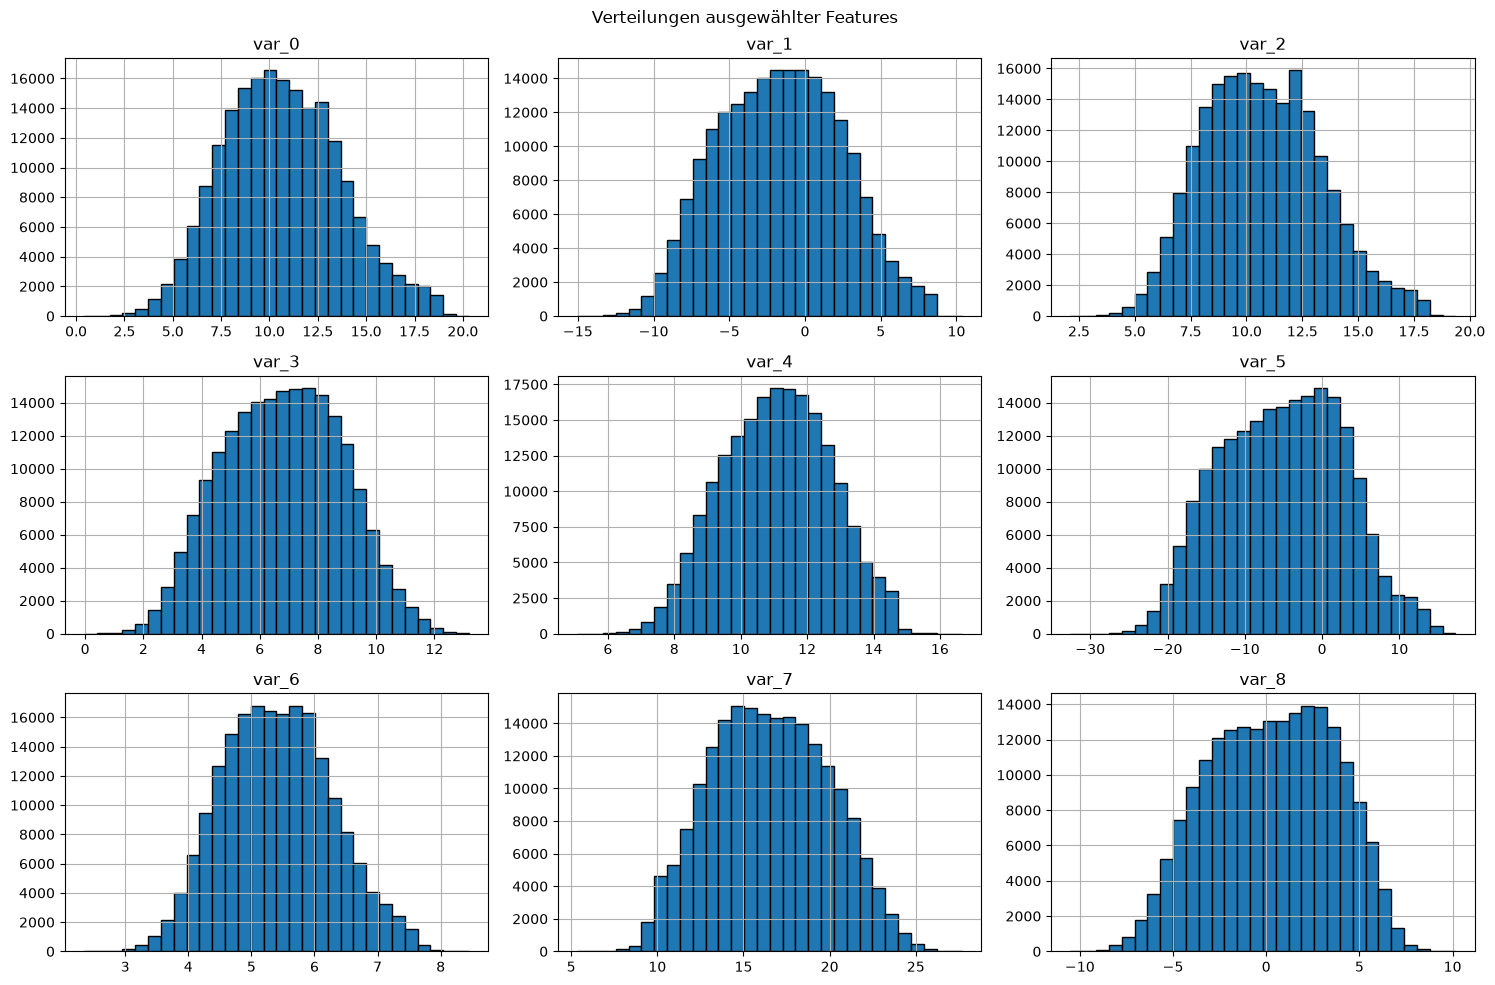

In [13]:
selected_features = feature_columns[:9]

if selected_features:
    df[selected_features].hist(
        bins=30,
        figsize=(15, 10),
        edgecolor="black"
    )
    plt.suptitle("Verteilungen ausgewählter Features")
    plt.tight_layout()
    plt.show()


## 12. Boxplots

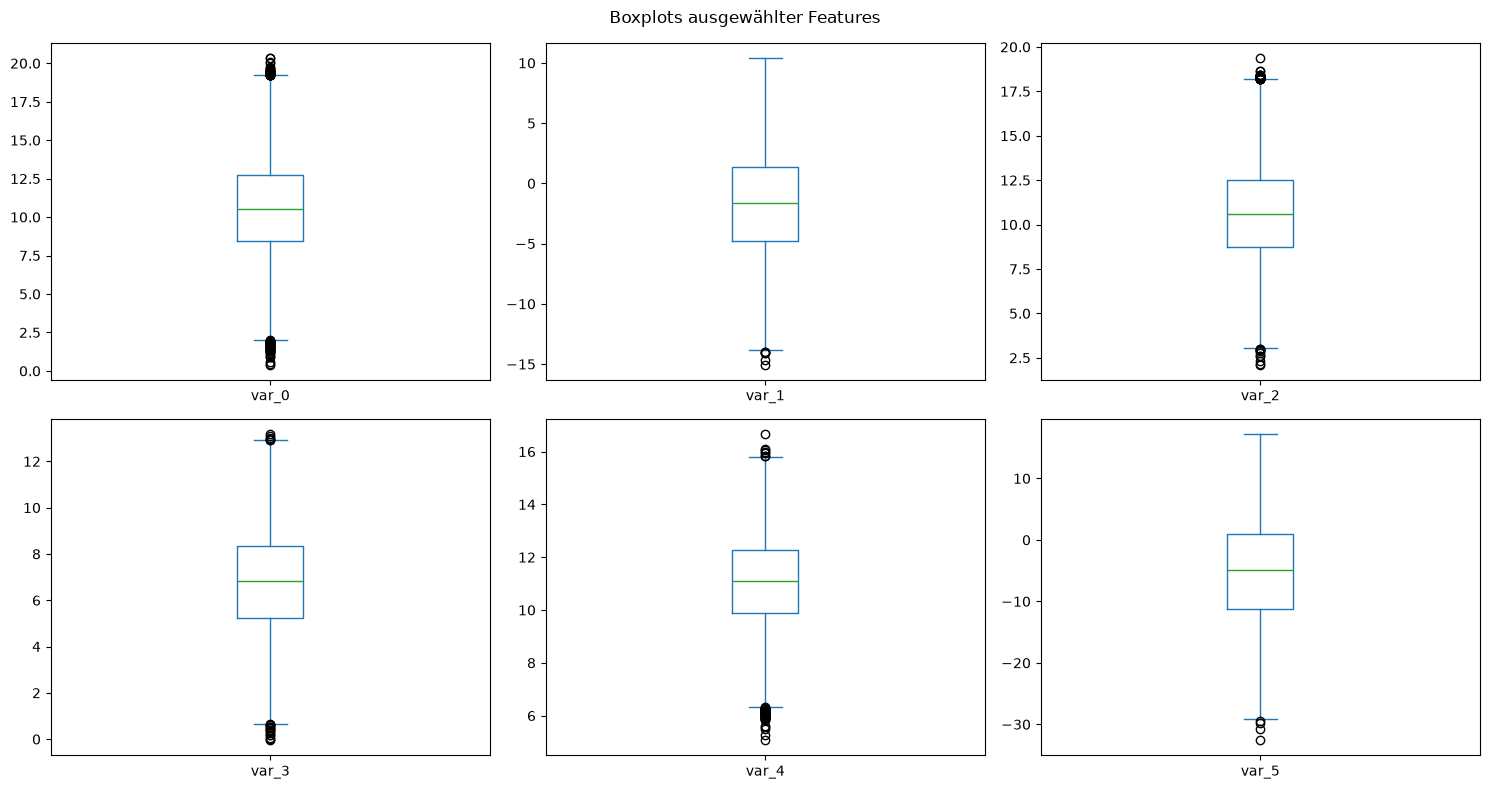

In [14]:
boxplot_features = feature_columns[:6]

if boxplot_features:
    df[boxplot_features].plot(
        kind="box",
        subplots=True,
        layout=(2, 3),
        figsize=(15, 8),
        sharex=False,
        sharey=False
    )
    plt.suptitle("Boxplots ausgewählter Features")
    plt.tight_layout()
    plt.show()


## 13. Klassenvergleich

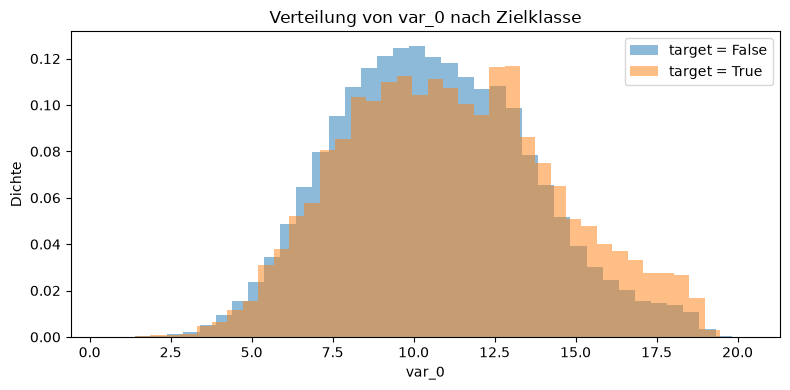

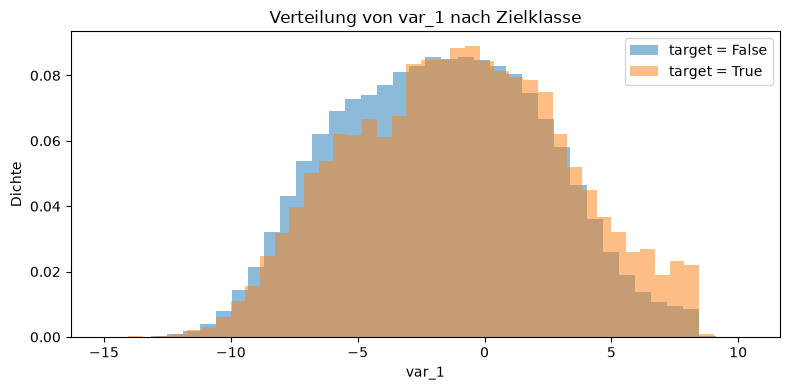

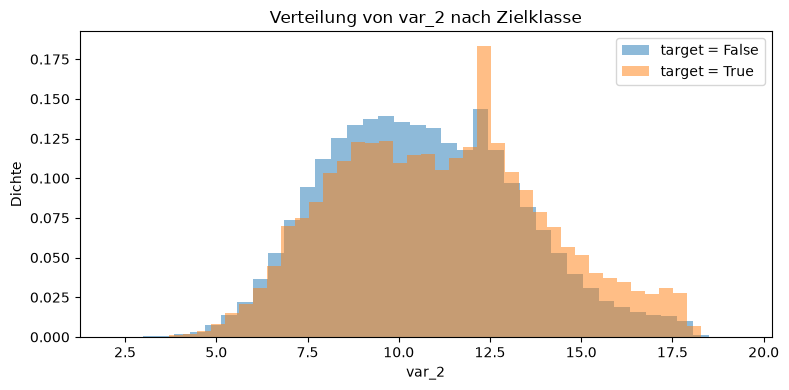

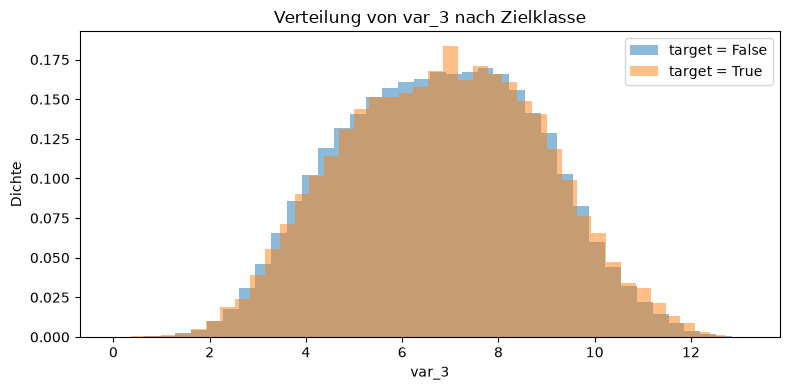

In [15]:
if TARGET_COLUMN and feature_columns:
    for feature in feature_columns[:4]:
        plt.figure(figsize=(8, 4))

        for target_value in sorted(df[TARGET_COLUMN].dropna().unique()):
            values = df.loc[
                df[TARGET_COLUMN] == target_value, feature
            ].dropna()

            plt.hist(
                values,
                bins=40,
                density=True,
                alpha=0.5,
                label=f"{TARGET_COLUMN} = {target_value}"
            )

        plt.title(f"Verteilung von {feature} nach Zielklasse")
        plt.xlabel(feature)
        plt.ylabel("Dichte")
        plt.legend()
        plt.tight_layout()
        plt.show()


## 14. Korrelationsmatrix

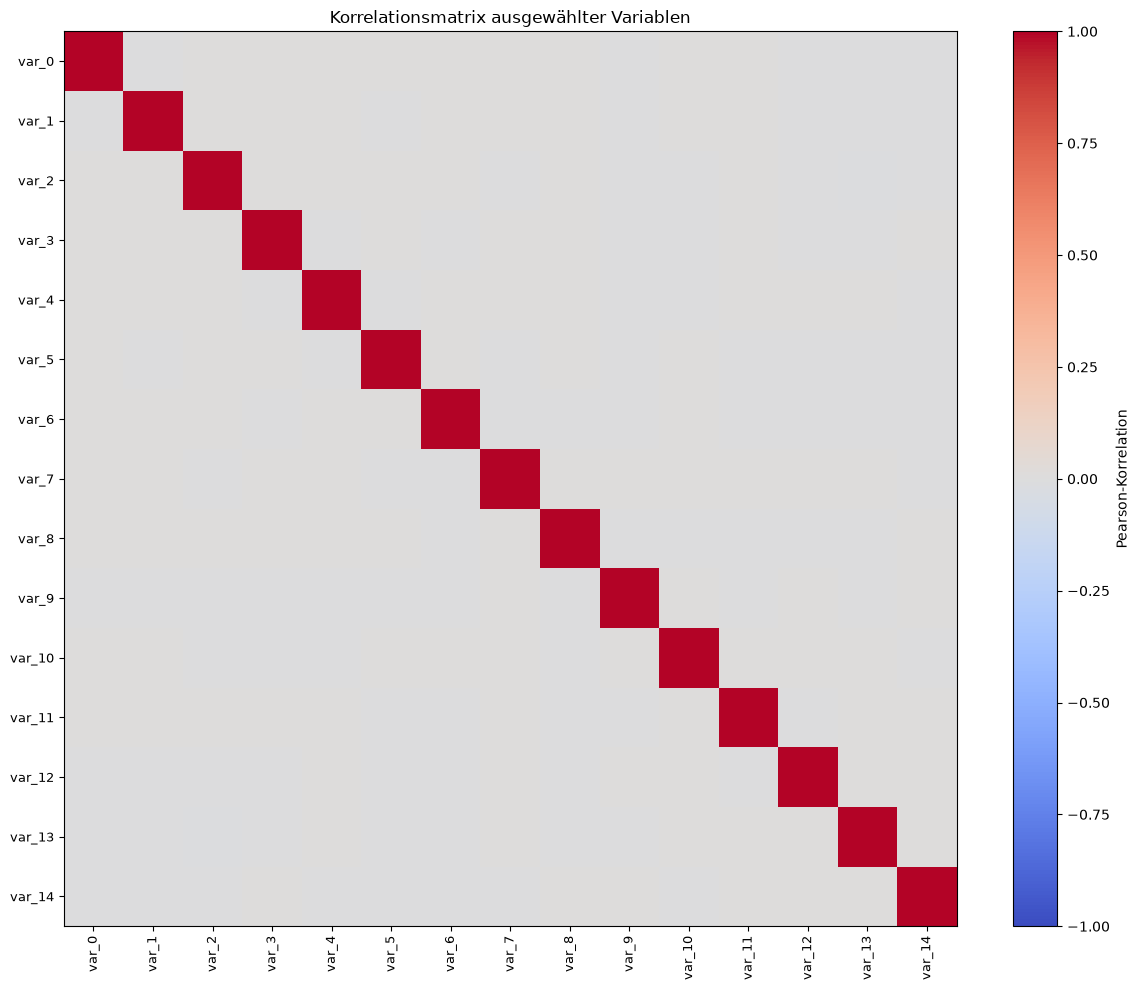

In [16]:
corr_features = feature_columns[:15]

if TARGET_COLUMN:
    corr_features = corr_features + [TARGET_COLUMN]

if len(corr_features) >= 2:
    # Nur numerische Spalten verwenden
    numeric_cols = df[corr_features].select_dtypes(include=["number"]).columns.tolist()
    
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols].corr()

        fig, ax = plt.subplots(figsize=(12, 10))
        image = ax.imshow(corr, vmin=-1, vmax=1, aspect="auto", cmap="coolwarm")

        ax.set_xticks(range(len(corr.columns)))
        ax.set_yticks(range(len(corr.index)))
        ax.set_xticklabels(corr.columns, rotation=90, fontsize=9)
        ax.set_yticklabels(corr.index, fontsize=9)

        plt.colorbar(image, ax=ax, label="Pearson-Korrelation")
        plt.title("Korrelationsmatrix ausgewählter Variablen")
        plt.tight_layout()
        plt.show()


## 15. Stärkste Korrelationen mit dem Target

In [17]:
if TARGET_COLUMN and feature_columns:
    # Nur numerische Features mit numerischem Target verwenden
    try:
        numeric_features = [c for c in feature_columns if df[c].dtype in ["int64", "float64", "float32"]]
        if numeric_features and df[TARGET_COLUMN].dtype in ["int64", "float64", "float32"]:
            target_corr = (
                df[numeric_features + [TARGET_COLUMN]]
                .corr(numeric_only=True)[TARGET_COLUMN]
                .drop(TARGET_COLUMN)
                .sort_values(key=np.abs, ascending=False)
            )

            display(target_corr.head(20).rename("Korrelation_mit_Target"))

            target_corr.head(20).sort_values().plot(
                kind="barh",
                figsize=(9, 7),
                edgecolor="black"
            )
            plt.title("Top-20-Features nach absoluter Target-Korrelation")
            plt.xlabel("Pearson-Korrelation")
            plt.ylabel("Feature")
            plt.tight_layout()
            plt.show()
        else:
            print("Zielvariable oder Features sind nicht numerisch.")
    except Exception as e:
        print(f"Fehler bei Korrelationsberechnung: {e}")


Zielvariable oder Features sind nicht numerisch.


## 16. Automatische Zusammenfassung

In [18]:
summary = {
    "Datei": FILE_PATH.name,
    "Erkanntes Format": detected_format,
    "Zeilen": int(df.shape[0]),
    "Spalten": int(df.shape[1]),
    "Numerische Spalten": int(len(numeric_columns)),
    "Fehlende Werte": int(df.isna().sum().sum()),
    "Doppelte Zeilen": int(df.duplicated().sum()),
    "Konstante Spalten": int(len(constant_columns)),
    "RAM_MB": round(df.memory_usage(deep=True).sum() / 1024**2, 2)
}

if TARGET_COLUMN:
    # Nur für numerische Zielvariable
    if df[TARGET_COLUMN].dtype in ["int64", "float64", "float32"]:
        summary["Anteil positive Klasse (%)"] = round(
            100 * df[TARGET_COLUMN].mean(), 2
        )
    else:
        # Für kategorische Zielvariable: Häufigste Klasse
        summary["Häufigste Klasse"] = df[TARGET_COLUMN].value_counts().idxmax()
        summary["Klasse-Verteilung"] = df[TARGET_COLUMN].value_counts().to_dict()

display(pd.DataFrame(summary.items(), columns=["Merkmal", "Wert"]))


,Merkmal,Wert
0,Datei,dataset
1,Erkanntes Format,ARFF
2,Zeilen,200000
3,Spalten,201
4,Numerische Spalten,200
5,Fehlende Werte,0
6,Doppelte Zeilen,0
7,Konstante Spalten,0
8,RAM_MB,315.4600
9,Häufigste Klasse,False


## 17. Eigene Erkenntnisse für das Logbuch

1. Datensatzgröße und Struktur:  
2. Datentypen und Speicherbedarf:  
3. Fehlende Werte und Duplikate:  
4. Verteilung der Zielvariable:  
5. Auffällige Feature-Verteilungen:  
6. Korrelationen:  
7. Konsequenzen für Machine Learning:  
8. Grenzen der bisherigen Analyse:  

## Noch extern zu ergänzende Metadaten

- Autor/Herausgeber und Kontakt
- offizielles Erstellungsdatum
- letzte Aktualisierung
- Version
- Lizenz/Nutzungsbedingungen
- Erhebungszeitraum und -ort
- genaue Datenerhebungsmethode
- dokumentierte Vorverarbeitung
